In [27]:
import pandas as pd
import numpy as np
import optuna

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, balanced_accuracy_score
from xgboost import XGBClassifier

In [28]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

X = train.drop(columns=["id", "Irrigation_Need"])
y = train["Irrigation_Need"]

X_test = test.drop(columns=["id"])
test_ids = test["id"]

# one-hot encode for RF and XGBoost
X = pd.get_dummies(X, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# align columns
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [29]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scorer = make_scorer(balanced_accuracy_score)

In [30]:
sample_size = 100000 
train_sample = train.sample(sample_size, random_state=42)

X_sample = train_sample.drop(columns=["id", "Irrigation_Need"])
y_sample = train_sample["Irrigation_Need"]

X_sample = pd.get_dummies(X_sample, drop_first=True)
X_sample = X_sample.reindex(columns=X.columns, fill_value=0)

y_sample_encoded = le.transform(y_sample)


def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 400),
        "max_depth": trial.suggest_int("max_depth", 8, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    score = cross_val_score(
        model,
        X_sample,
        y_sample_encoded,
        cv=3,
        scoring="balanced_accuracy",
        n_jobs=-1
    ).mean()

    return score


study_rf = optuna.create_study(direction="maximize")

study_rf.optimize(objective_rf, n_trials=5)

print("Best RF score:", study_rf.best_value)
print("Best RF params:", study_rf.best_params)

[I 2026-04-30 03:01:12,378] A new study created in memory with name: no-name-5cc4a4da-9f3e-46f6-b3b1-03e21395c362
[I 2026-04-30 03:01:31,620] Trial 0 finished with value: 0.8035014135580446 and parameters: {'n_estimators': 374, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.8035014135580446.
[I 2026-04-30 03:01:47,543] Trial 1 finished with value: 0.9359130711106811 and parameters: {'n_estimators': 252, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.9359130711106811.
[I 2026-04-30 03:01:59,531] Trial 2 finished with value: 0.9410743691917086 and parameters: {'n_estimators': 208, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 2 with value: 0.9410743691917086.
[I 2026-04-30 03:02:08,666] Trial 3 finished with value: 0.7234827302536236 and parameters: {'n_estimators': 227, 'max_depth': 8, '

Best RF score: 0.9410743691917086
Best RF params: {'n_estimators': 208, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2'}


In [31]:
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X, y_encoded)

rf_preds = best_rf.predict(X_test)
rf_preds = le.inverse_transform(rf_preds)

bagging_submission = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": rf_preds
})

bagging_submission.to_csv("bagging_submission.csv", index=False)

In [32]:
sample_size = 100000 
train_sample = train.sample(sample_size, random_state=42)

X_sample = train_sample.drop(columns=["id", "Irrigation_Need"])
y_sample = train_sample["Irrigation_Need"]

X_sample = pd.get_dummies(X_sample, drop_first=True)
X_sample = X_sample.reindex(columns=X.columns, fill_value=0)

y_sample_encoded = le.transform(y_sample)


def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 500),
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "gamma": trial.suggest_float("gamma", 0, 2),
        "objective": "multi:softprob",
        "num_class": 3,
        "random_state": 42,
        "eval_metric": "mlogloss",
        "n_jobs": -1,
        "tree_method": "hist"
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_sample,  
        y_sample_encoded,
        cv=3,        
        scoring="balanced_accuracy",
        n_jobs=1                 
    ).mean()

    return score


study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=5)

print("Best XGB score:", study_xgb.best_value)
print("Best XGB params:", study_xgb.best_params)

[I 2026-04-30 03:03:48,801] A new study created in memory with name: no-name-dc848174-358a-4752-ae50-5667bef9f675
[I 2026-04-30 03:03:56,384] Trial 0 finished with value: 0.9568866435815133 and parameters: {'n_estimators': 404, 'max_depth': 5, 'learning_rate': 0.05349702672169575, 'subsample': 0.8765029479420576, 'colsample_bytree': 0.7311360549413792, 'min_child_weight': 1, 'gamma': 1.2155843290381594}. Best is trial 0 with value: 0.9568866435815133.
[I 2026-04-30 03:04:01,941] Trial 1 finished with value: 0.9580133539406411 and parameters: {'n_estimators': 344, 'max_depth': 7, 'learning_rate': 0.13746568815293095, 'subsample': 0.7234389183115006, 'colsample_bytree': 0.875026710563411, 'min_child_weight': 5, 'gamma': 1.7823940972255143}. Best is trial 1 with value: 0.9580133539406411.
[I 2026-04-30 03:04:09,508] Trial 2 finished with value: 0.9573192790586029 and parameters: {'n_estimators': 360, 'max_depth': 5, 'learning_rate': 0.05306651783878292, 'subsample': 0.8775400562989919, 'c

Best XGB score: 0.9580133539406411
Best XGB params: {'n_estimators': 344, 'max_depth': 7, 'learning_rate': 0.13746568815293095, 'subsample': 0.7234389183115006, 'colsample_bytree': 0.875026710563411, 'min_child_weight': 5, 'gamma': 1.7823940972255143}


In [33]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

best_xgb.fit(X, y_encoded)

xgb_preds = best_xgb.predict(X_test)
xgb_preds = le.inverse_transform(xgb_preds)

boosting_submission = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": xgb_preds
})

boosting_submission.to_csv("boosting_submission.csv", index=False)

## Week 4: 

In [34]:
import catboost as cb
import lightgbm as lgb

## CatBoost: Configuration Comparison

In [35]:
# CatBoost Configuration 1: Conservative (fewer iterations, shallow depth, high learning rate)
cb_config1 = cb.CatBoostClassifier(
    iterations=100,
    depth=3,
    learning_rate=0.1,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    min_data_in_leaf=5,
    random_state=42,
    verbose=False
)

cb_config1.fit(X, y_encoded)
cb_config1_preds = cb_config1.predict(X_test)
cb_config1_preds = le.inverse_transform(cb_config1_preds)

# Cross-validation score for comparison
cb_config1_score = cross_val_score(
    cb_config1,
    X,
    y_encoded,
    cv=cv,
    scoring="balanced_accuracy"
).mean()

print("CatBoost Config 1:")
print(f"  CV Balanced Accuracy: {cb_config1_score:.4f}")
print(f"  Parameters: iterations=100, depth=3, learning_rate=0.1, subsample=0.8")


CatBoost Config 1:
  CV Balanced Accuracy: 0.9496
  Parameters: iterations=100, depth=3, learning_rate=0.1, subsample=0.8


In [36]:
# CatBoost Configuration 2: Moderate (balanced approach)
cb_config2 = cb.CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    bootstrap_type='Bernoulli',
    subsample=0.9,
    min_data_in_leaf=2,
    random_state=42,
    verbose=False
)

cb_config2.fit(X, y_encoded)
cb_config2_preds = cb_config2.predict(X_test)
cb_config2_preds = le.inverse_transform(cb_config2_preds)

cb_config2_score = cross_val_score(
    cb_config2,
    X,
    y_encoded,
    cv=cv,
    scoring="balanced_accuracy"
).mean()

print("CatBoost Config 2:")
print(f"  CV Balanced Accuracy: {cb_config2_score:.4f}")
print(f"  Parameters: iterations=300, depth=5, learning_rate=0.05, subsample=0.9")


CatBoost Config 2:
  CV Balanced Accuracy: 0.9601
  Parameters: iterations=300, depth=5, learning_rate=0.05, subsample=0.9


In [37]:
# CatBoost Configuration 3: Aggressive (more iterations, deeper trees, aggressive learning)
cb_config3 = cb.CatBoostClassifier(
    iterations=500,
    depth=7,
    learning_rate=0.15,
    bootstrap_type='Bernoulli',
    subsample=0.95,
    min_data_in_leaf=1,
    random_state=42,
    verbose=False
)

cb_config3.fit(X, y_encoded)
cb_config3_preds = cb_config3.predict(X_test)
cb_config3_preds = le.inverse_transform(cb_config3_preds)

cb_config3_score = cross_val_score(
    cb_config3,
    X,
    y_encoded,
    cv=cv,
    scoring="balanced_accuracy"
).mean()

print("CatBoost Config 3:")
print(f"  CV Balanced Accuracy: {cb_config3_score:.4f}")
print(f"  Parameters: iterations=500, depth=7, learning_rate=0.15, subsample=0.95")

print("\nCatBoost Summary:")
print(f"  Config 1: {cb_config1_score:.4f}")
print(f"  Config 2: {cb_config2_score:.4f}")
print(f"  Config 3: {cb_config3_score:.4f}")

# Choose best CatBoost model for submission
cb_configs = [
    (cb_config1_preds, cb_config1_score, "CB_Config1"),
    (cb_config2_preds, cb_config2_score, "CB_Config2"),
    (cb_config3_preds, cb_config3_score, "CB_Config3")
]

best_cb_preds, best_cb_score, best_cb_name = max(cb_configs, key=lambda x: x[1])

cb_submission = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": best_cb_preds
})

cb_submission.to_csv(f"cb_{best_cb_name}.csv", index=False)
print(f"\nBest CatBoost: {best_cb_name} with score {best_cb_score:.4f}")


CatBoost Config 3:
  CV Balanced Accuracy: 0.9613
  Parameters: iterations=500, depth=7, learning_rate=0.15, subsample=0.95

CatBoost Summary:
  Config 1: 0.9496
  Config 2: 0.9601
  Config 3: 0.9613

Best CatBoost: CB_Config3 with score 0.9613


## LightGBM: Configuration Comparison

In [38]:
# LightGBM Configuration 1:  (fewer leaves)
lgb_config1 = lgb.LGBMClassifier(
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=100,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_config1.fit(X, y_encoded)
lgb_config1_preds = lgb_config1.predict(X_test)
lgb_config1_preds = le.inverse_transform(lgb_config1_preds)

lgb_config1_score = cross_val_score(
    lgb_config1,
    X,
    y_encoded,
    cv=cv,
    scoring="balanced_accuracy"
).mean()

print("LightGBM Config 1:")
print(f"  CV Balanced Accuracy: {lgb_config1_score:.4f}")
print(f"  Parameters: num_leaves=31, learning_rate=0.1, n_estimators=100, min_child_samples=20")


LightGBM Config 1:
  CV Balanced Accuracy: 0.9615
  Parameters: num_leaves=31, learning_rate=0.1, n_estimators=100, min_child_samples=20


In [39]:
# LightGBM Configuration 2: 
lgb_config2 = lgb.LGBMClassifier(
    num_leaves=63,
    learning_rate=0.05,
    n_estimators=300,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    verbose=-1
)

lgb_config2.fit(X, y_encoded)
lgb_config2_preds = lgb_config2.predict(X_test)
lgb_config2_preds = le.inverse_transform(lgb_config2_preds)

lgb_config2_score = cross_val_score(
    lgb_config2,
    X,
    y_encoded,
    cv=cv,
    scoring="balanced_accuracy"
).mean()

print("LightGBM Config 2:")
print(f"  CV Balanced Accuracy: {lgb_config2_score:.4f}")
print(f"  Parameters: num_leaves=63, learning_rate=0.05, n_estimators=300, min_child_samples=10")


LightGBM Config 2:
  CV Balanced Accuracy: 0.9616
  Parameters: num_leaves=63, learning_rate=0.05, n_estimators=300, min_child_samples=10


In [40]:
# LightGBM Configuration 3:  (more leaves, less regularization)
lgb_config3 = lgb.LGBMClassifier(
    num_leaves=127,
    learning_rate=0.15,
    n_estimators=500,
    min_child_samples=5,
    subsample=0.95,
    colsample_bytree=0.95,
    random_state=42,
    verbose=-1
)

lgb_config3.fit(X, y_encoded)
lgb_config3_preds = lgb_config3.predict(X_test)
lgb_config3_preds = le.inverse_transform(lgb_config3_preds)

lgb_config3_score = cross_val_score(
    lgb_config3,
    X,
    y_encoded,
    cv=cv,
    scoring="balanced_accuracy"
).mean()

print("LightGBM Config 3:")
print(f"  CV Balanced Accuracy: {lgb_config3_score:.4f}")
print(f"  Parameters: num_leaves=127, learning_rate=0.15, n_estimators=500, min_child_samples=5")

print("\nLightGBM Summary:")
print(f"  Config 1: {lgb_config1_score:.4f}")
print(f"  Config 2: {lgb_config2_score:.4f}")
print(f"  Config 3: {lgb_config3_score:.4f}")

# Choose best LightGBM model for submission
lgb_configs = [
    (lgb_config1_preds, lgb_config1_score, "LGB_Config1"),
    (lgb_config2_preds, lgb_config2_score, "LGB_Config2"),
    (lgb_config3_preds, lgb_config3_score, "LGB_Config3")
]

best_lgb_preds, best_lgb_score, best_lgb_name = max(lgb_configs, key=lambda x: x[1])

lgb_submission = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": best_lgb_preds
})

lgb_submission.to_csv(f"lgb_{best_lgb_name}.csv", index=False)
print(f"\nBest LightGBM: {best_lgb_name} with score {best_lgb_score:.4f}")


LightGBM Config 3:
  CV Balanced Accuracy: 0.9600
  Parameters: num_leaves=127, learning_rate=0.15, n_estimators=500, min_child_samples=5

LightGBM Summary:
  Config 1: 0.9615
  Config 2: 0.9616
  Config 3: 0.9600

Best LightGBM: LGB_Config2 with score 0.9616


## Model Comparison & Ensemble

In [41]:
# Comprehensive model comparison
print("\nBOOSTING MODEL COMPARISON")
print()

all_models = [
    ("XGBoost (Optuna-tuned)", study_xgb.best_value),
    ("CatBoost Config 1", cb_config1_score),
    ("CatBoost Config 2", cb_config2_score),
    ("CatBoost Config 3", cb_config3_score),
    ("LightGBM Config 1", lgb_config1_score),
    ("LightGBM Config 2", lgb_config2_score),
    ("LightGBM Config 3", lgb_config3_score),
]

# Sort by score
sorted_models = sorted(all_models, key=lambda x: x[1], reverse=True)

print(f"\n{'Model':<40} {'CV Balanced Accuracy':<20}")
for i, (name, score) in enumerate(sorted_models, 1):
    print(f"{i}. {name:<38} {score:.4f}")


BOOSTING MODEL COMPARISON


Model                                    CV Balanced Accuracy
1. LightGBM Config 2                      0.9616
2. LightGBM Config 1                      0.9615
3. CatBoost Config 3                      0.9613
4. CatBoost Config 2                      0.9601
5. LightGBM Config 3                      0.9600
6. XGBoost (Optuna-tuned)                 0.9580
7. CatBoost Config 1                      0.9496


## Week 5

In [42]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.inspection import permutation_importance
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Feature Engineering

In [43]:
# reload raw data so we can engineer features before encoding
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

def engineer_features(df):
    d = df.copy()

    # interaction: temperature x humidity — hot and humid fields need more water
    d['temp_x_humidity'] = d['Temperature_C'] * d['Humidity']

    # interaction: rainfall x soil moisture — combined water availability signal
    d['rain_x_moisture'] = d['Rainfall_mm'] * d['Soil_Moisture']

    # transformation: log rainfall to compress the right tail
    d['log_rainfall'] = np.log1p(d['Rainfall_mm'])

    # transformation: log previous irrigation for same reason
    d['log_prev_irrigation'] = np.log1p(d['Previous_Irrigation_mm'])

    # grouping: bin soil pH into acidic / neutral / alkaline
    d['ph_bucket'] = pd.cut(
        d['Soil_pH'],
        bins=[0, 6.0, 7.5, 14],
        labels=['acidic', 'neutral', 'alkaline']
    ).astype(str)

    # grouping: bin field area into small / medium / large
    d['area_bucket'] = pd.cut(
        d['Field_Area_hectare'],
        bins=[0, 5, 15, 100],
        labels=['small', 'medium', 'large']
    ).astype(str)

    # interaction: crop type + season combo as a single category
    d['crop_season'] = d['Crop_Type'] + '_' + d['Season']

    return d

train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

new_cols = ['temp_x_humidity', 'rain_x_moisture', 'log_rainfall',
            'log_prev_irrigation', 'ph_bucket', 'area_bucket', 'crop_season']
print("new features:", new_cols)
print(train_fe[new_cols].head())

new features: ['temp_x_humidity', 'rain_x_moisture', 'log_rainfall', 'log_prev_irrigation', 'ph_bucket', 'area_bucket', 'crop_season']
   temp_x_humidity  rain_x_moisture  log_rainfall  log_prev_irrigation  \
0         759.6561       23652.7542      6.588913             4.728803   
1        1555.3512       55798.2126      6.894326             3.874529   
2        2487.1734       61009.1070      7.697439             4.712948   
3         820.1124       18079.6356      7.214011             4.004602   
4        1842.2442       90969.1480      7.339018             4.545314   

  ph_bucket area_bucket     crop_season  
0    acidic       small  Sugarcane_Zaid  
1   neutral      medium    Wheat_Kharif  
2    acidic      medium     Rice_Kharif  
3    acidic      medium    Wheat_Kharif  
4  alkaline      medium      Wheat_Rabi  


In [44]:
# prepare engineered feature matrices
X_fe = train_fe.drop(columns=["id", "Irrigation_Need"])
y_fe = train_fe["Irrigation_Need"]
X_fe_test = test_fe.drop(columns=["id"])

X_fe = pd.get_dummies(X_fe, drop_first=True)
X_fe_test = pd.get_dummies(X_fe_test, drop_first=True)
X_fe_test = X_fe_test.reindex(columns=X_fe.columns, fill_value=0)

le_fe = LabelEncoder()
y_fe_encoded = le_fe.fit_transform(y_fe)

print(f"feature count (original): {X.shape[1]}")
print(f"feature count (engineered): {X_fe.shape[1]}")

feature count (original): 35
feature count (engineered): 59


### Model: Extra Trees

In [45]:
# Extra Trees differs from Random Forest in how splits are chosen:
# RF searches for the best split threshold per feature, ET picks thresholds randomly.
# This makes ET faster and often more regularized, which can help on noisy data.
# Tuning with Optuna on a 100k sample to keep runtime reasonable.

sample_size = 100000
train_sample_fe = train_fe.sample(sample_size, random_state=42)
X_sample_fe = train_sample_fe.drop(columns=["id", "Irrigation_Need"])
y_sample_fe = train_sample_fe["Irrigation_Need"]
X_sample_fe = pd.get_dummies(X_sample_fe, drop_first=True)
X_sample_fe = X_sample_fe.reindex(columns=X_fe.columns, fill_value=0)
y_sample_fe_encoded = le_fe.transform(y_sample_fe)


def objective_et(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 500),
        "max_depth": trial.suggest_int("max_depth", 10, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }
    model = ExtraTreesClassifier(**params)
    score = cross_val_score(
        model, X_sample_fe, y_sample_fe_encoded,
        cv=3, scoring="balanced_accuracy", n_jobs=-1
    ).mean()
    return score


study_et = optuna.create_study(direction="maximize")
study_et.optimize(objective_et, n_trials=10)

print("Best ET score:", round(study_et.best_value, 4))
print("Best ET params:", study_et.best_params)

[I 2026-04-30 03:11:59,117] A new study created in memory with name: no-name-664e4e5b-5bea-4c3a-a960-64005c341e0f
[I 2026-04-30 03:12:29,182] Trial 0 finished with value: 0.6404560330085077 and parameters: {'n_estimators': 466, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.6404560330085077.
[I 2026-04-30 03:12:47,052] Trial 1 finished with value: 0.6345018238431587 and parameters: {'n_estimators': 413, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.6404560330085077.
[I 2026-04-30 03:13:21,008] Trial 2 finished with value: 0.71419368565551 and parameters: {'n_estimators': 499, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.71419368565551.
[I 2026-04-30 03:13:48,119] Trial 3 finished with value: 0.7243523683848455 and parameters: {'n_estimators': 406, 'max_depth': 23, 'min_s

Best ET score: 0.7552
Best ET params: {'n_estimators': 252, 'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


In [46]:
# fit best ET on full engineered training data
best_et = ExtraTreesClassifier(
    **study_et.best_params,
    random_state=42,
    n_jobs=-1
)
best_et.fit(X_fe, y_fe_encoded)

et_score = cross_val_score(
    best_et, X_fe, y_fe_encoded,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="balanced_accuracy"
).mean()

print(f"ET CV balanced accuracy (engineered features): {et_score:.4f}")

# also score ET on original features to see if engineering helped
et_base = ExtraTreesClassifier(**study_et.best_params, random_state=42, n_jobs=-1)
et_base_score = cross_val_score(
    et_base, X, y_encoded,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="balanced_accuracy"
).mean()

print(f"ET CV balanced accuracy (original features):   {et_base_score:.4f}")
print(f"feature engineering delta: {et_score - et_base_score:+.4f}")

ET CV balanced accuracy (engineered features): 0.8247
ET CV balanced accuracy (original features):   0.7830
feature engineering delta: +0.0418


### Feature Importance

In [47]:
# permutation importance on a held-out validation split
# using the best LGB model (highest CV score from week 4) on engineered features
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_fe, y_fe_encoded, test_size=0.2, stratify=y_fe_encoded, random_state=42
)

lgb_fe = lgb.LGBMClassifier(
    num_leaves=63,
    learning_rate=0.05,
    n_estimators=300,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    verbose=-1
)
lgb_fe.fit(X_tr, y_tr)

perm = permutation_importance(
    lgb_fe, X_val, y_val,
    n_repeats=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_fe.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("top 15 features by permutation importance:")
print(perm_df.head(15).to_string(index=False))

print("\nbottom 10 features (candidates to drop):")
print(perm_df.tail(10).to_string(index=False))

top 15 features by permutation importance:
                     feature  importance_mean  importance_std
               Soil_Moisture         0.342261        0.003150
               Temperature_C         0.199898        0.002503
           Mulching_Used_Yes         0.185745        0.001347
              Wind_Speed_kmh         0.172138        0.001168
   Crop_Growth_Stage_Harvest         0.168492        0.002190
    Crop_Growth_Stage_Sowing         0.147524        0.001272
                 Rainfall_mm         0.070421        0.000357
             rain_x_moisture         0.005926        0.000428
                log_rainfall         0.001912        0.000132
Crop_Growth_Stage_Vegetative         0.001536        0.000089
      Previous_Irrigation_mm         0.001230        0.000142
                    Humidity         0.000986        0.000137
              Sunlight_Hours         0.000483        0.000274
              Organic_Carbon         0.000376        0.000129
             temp_x_humidit

top 15 features by mean |SHAP|:
                     feature  mean_abs_shap
               Soil_Moisture       1.295144
   Crop_Growth_Stage_Harvest       0.857853
    Crop_Growth_Stage_Sowing       0.851522
           Mulching_Used_Yes       0.719329
              Wind_Speed_kmh       0.640083
               Temperature_C       0.556050
             rain_x_moisture       0.209130
                 Rainfall_mm       0.113655
                    Humidity       0.081623
      Previous_Irrigation_mm       0.075446
Crop_Growth_Stage_Vegetative       0.074177
              Sunlight_Hours       0.046990
             temp_x_humidity       0.033685
      Water_Source_Reservoir       0.033336
              Organic_Carbon       0.030914


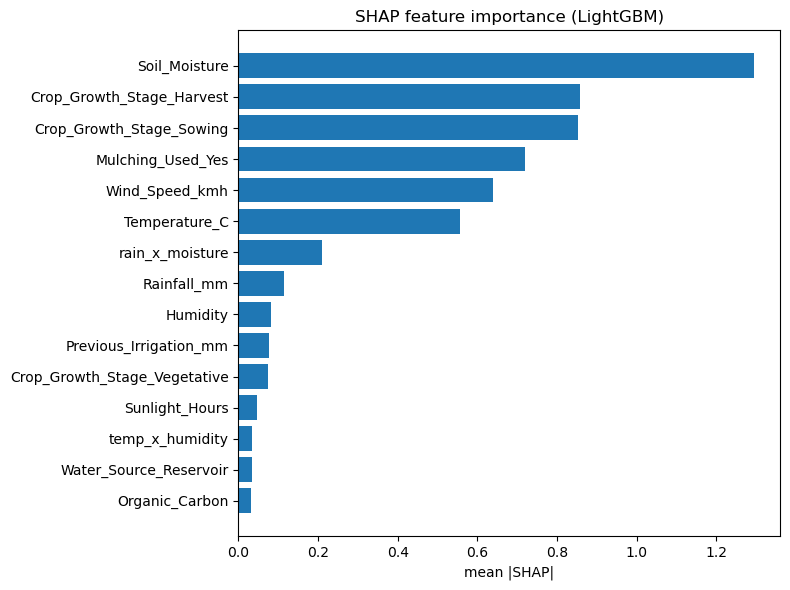

In [48]:
# SHAP values on a 500-row subsample for speed
shap_sample = X_val.sample(500, random_state=42)

explainer = shap.TreeExplainer(lgb_fe)
shap_values = explainer.shap_values(shap_sample)

# LightGBM returns (n_samples, n_features, n_classes) — average abs over samples and classes
sv = np.array(shap_values)
if sv.ndim == 3:
    mean_abs_shap = np.abs(sv).mean(axis=(0, 2))  # -> (n_features,)
else:
    mean_abs_shap = np.abs(sv).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": shap_sample.columns[:len(mean_abs_shap)],
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print("top 15 features by mean |SHAP|:")
print(shap_df.head(15).to_string(index=False))

# bar plot of top 15
top15 = shap_df.head(15)
plt.figure(figsize=(8, 6))
plt.barh(top15["feature"][::-1], top15["mean_abs_shap"][::-1])
plt.xlabel("mean |SHAP|")
plt.title("SHAP feature importance (LightGBM)")
plt.tight_layout()
plt.savefig("shap_beeswarm_w5.png", dpi=100, bbox_inches='tight')
plt.show()

In [49]:
# identify which engineered features made the top 15 in both methods
top15_perm = set(perm_df.head(15)["feature"].tolist())
top15_shap = set(shap_df.head(15)["feature"].tolist())
engineered = set(new_cols)

# expand engineered cols to include their dummied versions
engineered_expanded = set()
for col in X_fe.columns:
    for eng in new_cols:
        if col.startswith(eng):
            engineered_expanded.add(col)

print("engineered features in top 15 (permutation):", top15_perm & engineered_expanded)
print("engineered features in top 15 (SHAP):       ", top15_shap & engineered_expanded)

engineered features in top 15 (permutation): {'log_rainfall', 'temp_x_humidity', 'rain_x_moisture'}
engineered features in top 15 (SHAP):        {'temp_x_humidity', 'rain_x_moisture'}


### Ensemble: Probability Averaging

In [50]:
# ensemble the three best models from weeks 3-5:
# LGB Config 2 (0.9616), CatBoost Config 3 (0.9613), Extra Trees (engineered features)
# all retrained on the engineered feature set for a fair comparison

lgb_ens = lgb.LGBMClassifier(
    num_leaves=63, learning_rate=0.05, n_estimators=300,
    min_child_samples=10, subsample=0.9, colsample_bytree=0.9,
    random_state=42, verbose=-1
)

cb_ens = cb.CatBoostClassifier(
    iterations=500, depth=7, learning_rate=0.15,
    bootstrap_type='Bernoulli', subsample=0.95,
    min_data_in_leaf=1, random_state=42, verbose=False
)

et_ens = ExtraTreesClassifier(
    **study_et.best_params, random_state=42, n_jobs=-1
)

# cross-validate each on engineered features
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgb_ens_score = cross_val_score(lgb_ens, X_fe, y_fe_encoded, cv=cv3, scoring="balanced_accuracy").mean()
cb_ens_score  = cross_val_score(cb_ens,  X_fe, y_fe_encoded, cv=cv3, scoring="balanced_accuracy").mean()
et_ens_score  = cross_val_score(et_ens,  X_fe, y_fe_encoded, cv=cv3, scoring="balanced_accuracy").mean()

print(f"LGB (engineered) CV: {lgb_ens_score:.4f}")
print(f"CB  (engineered) CV: {cb_ens_score:.4f}")
print(f"ET  (engineered) CV: {et_ens_score:.4f}")

LGB (engineered) CV: 0.9619
CB  (engineered) CV: 0.9612
ET  (engineered) CV: 0.8247


In [51]:
# fit all three on full training data
lgb_ens.fit(X_fe, y_fe_encoded)
cb_ens.fit(X_fe, y_fe_encoded)
et_ens.fit(X_fe, y_fe_encoded)

# get predicted probabilities on test set
lgb_probs = lgb_ens.predict_proba(X_fe_test)
cb_probs  = cb_ens.predict_proba(X_fe_test)
et_probs  = et_ens.predict_proba(X_fe_test)

# equal-weight average
avg_probs = (lgb_probs + cb_probs + et_probs) / 3
ensemble_preds = le_fe.inverse_transform(np.argmax(avg_probs, axis=1))

ensemble_submission = pd.DataFrame({
    "id": test_df["id"],
    "Irrigation_Need": ensemble_preds
})
ensemble_submission.to_csv("ensemble_submission_w5.csv", index=False)
print("ensemble submission saved")

ensemble submission saved


In [52]:
# evaluate ensemble vs individual models using a held-out validation split
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_fe, y_fe_encoded, test_size=0.2, stratify=y_fe_encoded, random_state=42
)

lgb_v = lgb.LGBMClassifier(
    num_leaves=63, learning_rate=0.05, n_estimators=300,
    min_child_samples=10, subsample=0.9, colsample_bytree=0.9,
    random_state=42, verbose=-1
)
cb_v = cb.CatBoostClassifier(
    iterations=500, depth=7, learning_rate=0.15,
    bootstrap_type='Bernoulli', subsample=0.95,
    min_data_in_leaf=1, random_state=42, verbose=False
)
et_v = ExtraTreesClassifier(**study_et.best_params, random_state=42, n_jobs=-1)

lgb_v.fit(X_tr2, y_tr2)
cb_v.fit(X_tr2, y_tr2)
et_v.fit(X_tr2, y_tr2)

lgb_val_score = balanced_accuracy_score(y_val2, lgb_v.predict(X_val2))
cb_val_score  = balanced_accuracy_score(y_val2, cb_v.predict(X_val2))
et_val_score  = balanced_accuracy_score(y_val2, et_v.predict(X_val2))

# ensemble on val
avg_val = (lgb_v.predict_proba(X_val2) + cb_v.predict_proba(X_val2) + et_v.predict_proba(X_val2)) / 3
ens_val_score = balanced_accuracy_score(y_val2, np.argmax(avg_val, axis=1))

print(f"val balanced accuracy:")
print(f"  LGB:      {lgb_val_score:.4f}")
print(f"  CB:       {cb_val_score:.4f}")
print(f"  ET:       {et_val_score:.4f}")
print(f"  Ensemble: {ens_val_score:.4f}")
best_individual = max(lgb_val_score, cb_val_score, et_val_score)
print(f"  ensemble delta vs best individual: {ens_val_score - best_individual:+.4f}")

val balanced accuracy:
  LGB:      0.9648
  CB:       0.9649
  ET:       0.8374
  Ensemble: 0.9636
  ensemble delta vs best individual: -0.0013
